In [3]:
import pandas as pd
import numpy as np
import os

In [1]:
from sklearn.model_selection import train_test_split


from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

from sklearn import metrics
from sklearn.feature_selection import SelectFromModel

import lightgbm as lgbm


In [4]:
data = pd.read_csv(os.getcwd()+"\\data\\data.csv")

In [5]:
data.shape

(322448, 1337)

Split onto train/test 

In [6]:
x, y = data.drop(['soldPrice'], axis = 1), data['soldPrice']

In [7]:
import re
x = x.rename(columns = lambda z: re.sub('[^A-Za-z0-9_]+', '', z))

In [8]:
x.columns

Index(['originalPrice', 'listPrice', 'latitude', 'longitude', 'DOM',
       'avg_sqft', 'ppsqft', 'bathtobed_ratio', 'listPrice_by_area',
       'listPrice_by_city',
       ...
       'style_BungalowRaised', 'style_IndustrialLoft', 'style_Loft',
       'style_MultiLevel', 'style_Other', 'style_Sidesplit3',
       'style_Sidesplit4', 'style_Sidesplit5', 'style_StackedTownhse',
       'style_WarehouseLoft'],
      dtype='object', length=1336)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)

print('Shape of x_train: ' + str(x_train.shape))
print('Shape of y_train: ' + str(y_train.shape))
print('Shape of x_test: ' + str(x_test.shape))
print('Shape of y_test: ' + str(y_test.shape))

Shape of x_train: (225713, 1336)
Shape of y_train: (225713,)
Shape of x_test: (96735, 1336)
Shape of y_test: (96735,)


In [10]:
x_train.columns

Index(['originalPrice', 'listPrice', 'latitude', 'longitude', 'DOM',
       'avg_sqft', 'ppsqft', 'bathtobed_ratio', 'listPrice_by_area',
       'listPrice_by_city',
       ...
       'style_BungalowRaised', 'style_IndustrialLoft', 'style_Loft',
       'style_MultiLevel', 'style_Other', 'style_Sidesplit3',
       'style_Sidesplit4', 'style_Sidesplit5', 'style_StackedTownhse',
       'style_WarehouseLoft'],
      dtype='object', length=1336)

In [11]:
#Define XGBoost parameters tree_method = 'gpu_hist'
base_regressor = lgbm.LGBMRegressor(learning_rate = 0.3,random_state=0)

#Get top 100 features using XGBoost
select_feat = SelectFromModel(base_regressor,threshold=-np.inf,max_features=25).fit(x_train,y_train)

In [12]:
#Get indices of top 100 features 
feat_index = select_feat.get_support()

#Rename the columns of training and test sets to include column names of top 100 features
train_x = pd.DataFrame(x_train, columns = x_train.columns[feat_index])
test_x = pd.DataFrame(x_test, columns= x_test.columns[feat_index])


#Print the top 100 features
for col in x_train.columns[feat_index]:
    print(col)

originalPrice
listPrice
latitude
longitude
DOM
avg_sqft
ppsqft
bathtobed_ratio
listPrice_by_area
listPrice_by_city
city_EastLutherGrandValley
city_Markham
district_TorontoC01
neighborhood_GrandValley
neighborhood_OldMarkhamVillage
neighborhood_RuralInnisfil
numBathrooms_1
numBathrooms_2
numBathrooms_3
numBathrooms_4
numBedrooms_1
numBedrooms_3
numBedrooms_4
style_2Storey
style_Bungalow


<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

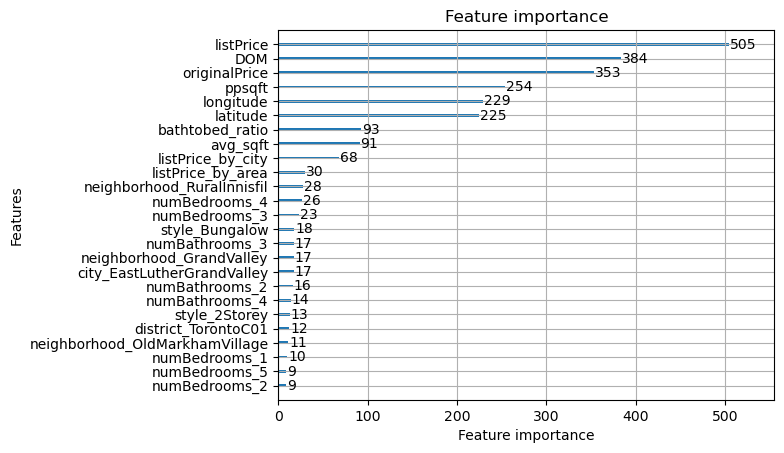

In [13]:
lgbm.plot_importance(base_regressor.fit(x_train,y_train), max_num_features = 25)

In [14]:
#LightGBM parameters
params = {
        'colsample_bytree': [0.5, 0.75, 1],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.25, 0.5, 1.0],
        'max_depth': [5, 7, 9, 11],
        'num_leaves': [15,30,45],
        'reg_lambda': [0.01, 0.5, 0.1],
        'min_child_samples': [10,20,30],
        }

In [15]:
#Define XGBoost base model 
# lgbm_model = lgbm.LGBMRegressor(n_estimators=100, device = 'gpu')

# grid_search = GridSearchCV(lgbm_model, params, cv=5,verbose=3)
# grid_search.fit(train_x, y_train)

Saving the grid search results

In [16]:
# #Get results of gridsearch 
# grid_results_df = pd.DataFrame(grid_search.cv_results_)
# #Save to csv
# grid_results_df.to_csv("GridSearch_CV_lease_results.csv", index = False)

Loading the grid search results

In [17]:
grid_results_df = pd.read_csv(os.getcwd()+"\\GridSearch_CV_lease_results.csv")
#grid_results_df.sort_values(by=['rank_test_score']).head()

In [18]:
import ast
params = ast.literal_eval(str(grid_results_df.sort_values(by=['rank_test_score'])['params'].values[0]))

In [19]:
best_model = lgbm.LGBMRegressor(n_estimators=100, device = 'gpu')
best_model.set_params(**params)

best_model = best_model.fit(train_x, y_train)
best_model

LGBMRegressor(colsample_bytree=1, device='gpu', max_depth=5,
              min_child_samples=10, num_leaves=15, reg_lambda=0.5,
              subsample=0.5)

In [20]:
y_pred = best_model.predict(test_x)

In [21]:
metrics.mean_absolute_error(y_test, y_pred)

52.53210621731104

In [22]:
metrics.r2_score(y_test, y_pred)

0.9815126615438714

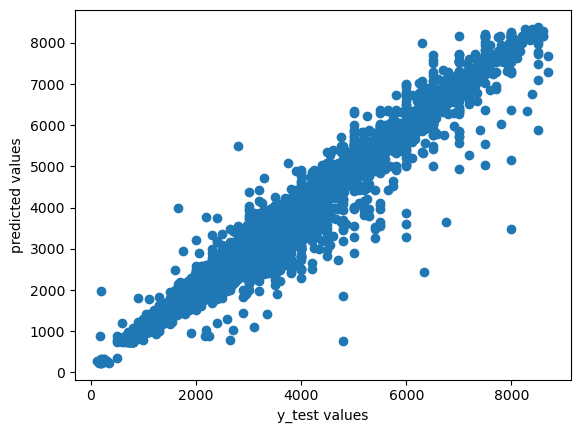

In [23]:
import matplotlib.pyplot as plt

plt.scatter(x = y_test.values,y =  y_pred)
plt.xlabel("y_test values")
plt.ylabel("predicted values")
plt.show()



sale

In [4]:
sale_data = pd.read_csv(os.getcwd()+"\\data\\sale_data.csv")

In [17]:
sale_data.shape

(239978, 1793)

In [19]:
'style_3Storey' in sale_data.columns

False

Split onto train/test 

In [24]:
x, y = sale_data.drop(['soldPrice'], axis = 1), sale_data['soldPrice']

In [29]:
for col in x.columns:
    print(col)

originalPrice
listPrice
latitude
longitude
DOM
avg_sqft
ppsqft
bathtobed_ratio
listPrice_by_area
listPrice_by_city
class_CondoProperty
class_ResidentialProperty
area_Algoma
area_Brant
area_Brantford
area_Bruce
area_Canada
area_Chatham-Kent
area_Cochrane
area_Dufferin
area_Durham
area_Elgin
area_Essex
area_Frontenac
area_Greater Sudbur
area_Grey County
area_Haldimand
area_Haliburton
area_Halton
area_Hamilton
area_Hastings
area_Huron
area_Kawartha Lakes
area_Kenora
area_Lambton
area_Lanark
area_Leeds & Grenvi
area_Lennox & Addin
area_Manitoulin
area_Middlesex
area_Muskoka
area_Niagara
area_Nipissing
area_Norfolk
area_Northumberland
area_Other Country
area_Ottawa
area_Oxford
area_Parry Sound
area_Peel
area_Perth
area_Peterborough
area_Prescott and R
area_Prince Edward 
area_Renfrew
area_Simcoe
area_Stormont, Dund
area_Sudbury
area_Thunder Bay
area_Timiskaming
area_Toronto
area_USA
area_Waterloo
area_Wellington
area_York
city_Addington Highlands
city_Adelaide Metcalfe
city_Adjala-Tosoronti

In [38]:
import re
x = x.rename(columns = lambda z: re.sub('[^A-Za-z0-9_\s]+', '', z))

In [35]:
for col in t.columns:
    print(col)

originalPrice
listPrice
latitude
longitude
DOM
avg_sqft
ppsqft
bathtobed_ratio
listPrice_by_area
listPrice_by_city
class_CondoProperty
class_ResidentialProperty
area_Algoma
area_Brant
area_Brantford
area_Bruce
area_Canada
area_ChathamKent
area_Cochrane
area_Dufferin
area_Durham
area_Elgin
area_Essex
area_Frontenac
area_Greater Sudbur
area_Grey County
area_Haldimand
area_Haliburton
area_Halton
area_Hamilton
area_Hastings
area_Huron
area_Kawartha Lakes
area_Kenora
area_Lambton
area_Lanark
area_Leeds  Grenvi
area_Lennox  Addin
area_Manitoulin
area_Middlesex
area_Muskoka
area_Niagara
area_Nipissing
area_Norfolk
area_Northumberland
area_Other Country
area_Ottawa
area_Oxford
area_Parry Sound
area_Peel
area_Perth
area_Peterborough
area_Prescott and R
area_Prince Edward 
area_Renfrew
area_Simcoe
area_Stormont Dund
area_Sudbury
area_Thunder Bay
area_Timiskaming
area_Toronto
area_USA
area_Waterloo
area_Wellington
area_York
city_Addington Highlands
city_Adelaide Metcalfe
city_AdjalaTosorontio
cit

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)

print('Shape of x_train: ' + str(x_train.shape))
print('Shape of y_train: ' + str(y_train.shape))
print('Shape of x_test: ' + str(x_test.shape))
print('Shape of y_test: ' + str(y_test.shape))

Shape of x_train: (167984, 1792)
Shape of y_train: (167984,)
Shape of x_test: (71994, 1792)
Shape of y_test: (71994,)


In [40]:
#Define XGBoost parameters tree_method = 'gpu_hist'
base_regressor = lgbm.LGBMRegressor(learning_rate = 0.3,random_state=0)

#Get top 100 features using XGBoost
select_feat = SelectFromModel(base_regressor,threshold=-np.inf,max_features=25).fit(x_train,y_train)

In [41]:
#Get indices of top 100 features 
feat_index = select_feat.get_support()

#Rename the columns of training and test sets to include column names of top 100 features
train_x = pd.DataFrame(x_train, columns = x_train.columns[feat_index])
test_x = pd.DataFrame(x_test, columns= x_test.columns[feat_index])


#Print the top 100 features
for col in x_train.columns[feat_index]:
    print(col)

originalPrice
listPrice
latitude
longitude
DOM
avg_sqft
ppsqft
bathtobed_ratio
listPrice_by_area
listPrice_by_city
class_CondoProperty
area_Durham
area_Toronto
city_LaSalle
city_Markham
numBathrooms_2
numBathrooms_3
numBathrooms_4
numBathrooms_5
numBedrooms_3
numBedrooms_4
style_2Storey
style_3Storey
style_Apartment
style_Bungalow


<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

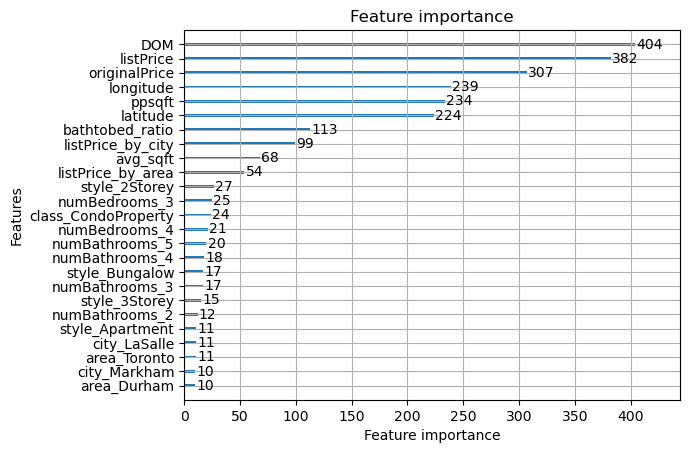

In [42]:
lgbm.plot_importance(base_regressor.fit(x_train,y_train), max_num_features = 25)

In [43]:
#LightGBM parameters
params = {
        'colsample_bytree': [0.5, 0.75, 1],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.25, 0.5, 1.0],
        'max_depth': [5, 7, 9, 11],
        'num_leaves': [15,30,45],
        'reg_lambda': [0.01, 0.5, 0.1],
        'min_child_samples': [10,20,30],
        }

In [50]:
#Define XGBoost base model 
lgbm_model = lgbm.LGBMRegressor(n_estimators=100, device = 'gpu')

grid_search = GridSearchCV(lgbm_model, params, cv=5,verbose=3)
grid_search.fit(train_x, y_train)

Fitting 5 folds for each of 2916 candidates, totalling 14580 fits
[CV 1/5] END colsample_bytree=0.5, learning_rate=0.01, max_depth=5, min_child_samples=10, num_leaves=15, reg_lambda=0.01, subsample=0.25;, score=0.793 total time=   0.8s
[CV 2/5] END colsample_bytree=0.5, learning_rate=0.01, max_depth=5, min_child_samples=10, num_leaves=15, reg_lambda=0.01, subsample=0.25;, score=0.793 total time=   1.0s
[CV 3/5] END colsample_bytree=0.5, learning_rate=0.01, max_depth=5, min_child_samples=10, num_leaves=15, reg_lambda=0.01, subsample=0.25;, score=0.794 total time=   0.8s
[CV 4/5] END colsample_bytree=0.5, learning_rate=0.01, max_depth=5, min_child_samples=10, num_leaves=15, reg_lambda=0.01, subsample=0.25;, score=0.791 total time=   0.8s
[CV 5/5] END colsample_bytree=0.5, learning_rate=0.01, max_depth=5, min_child_samples=10, num_leaves=15, reg_lambda=0.01, subsample=0.25;, score=0.794 total time=   0.9s
[CV 1/5] END colsample_bytree=0.5, learning_rate=0.01, max_depth=5, min_child_sample

GridSearchCV(cv=5, estimator=LGBMRegressor(device='gpu'),
             param_grid={'colsample_bytree': [0.5, 0.75, 1],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [5, 7, 9, 11],
                         'min_child_samples': [10, 20, 30],
                         'num_leaves': [15, 30, 45],
                         'reg_lambda': [0.01, 0.5, 0.1],
                         'subsample': [0.25, 0.5, 1.0]},
             verbose=3)

Saving the grid search results

In [51]:
#Get results of gridsearch 
grid_results_df = pd.DataFrame(grid_search.cv_results_)
#Save to csv
grid_results_df.to_csv("GridSearch_CV_sale_results.csv", index = False)

Loading the grid search results

In [52]:
grid_results_df = pd.read_csv(os.getcwd()+"\\GridSearch_CV_sale_results.csv")
#grid_results_df.sort_values(by=['rank_test_score']).head()

In [53]:
import ast
params = ast.literal_eval(str(grid_results_df.sort_values(by=['rank_test_score'])['params'].values[0]))

In [54]:
best_model = lgbm.LGBMRegressor(n_estimators=100, device = 'gpu')
best_model.set_params(**params)

best_model = best_model.fit(train_x, y_train)
best_model

LGBMRegressor(colsample_bytree=1, device='gpu', learning_rate=0.2, max_depth=9,
              min_child_samples=30, num_leaves=45, reg_lambda=0.1,
              subsample=0.25)

In [55]:
y_pred = best_model.predict(test_x)

In [56]:
metrics.mean_absolute_error(y_test, y_pred)

66017.56174296017

In [57]:
metrics.r2_score(y_test, y_pred)

0.9659467564213986

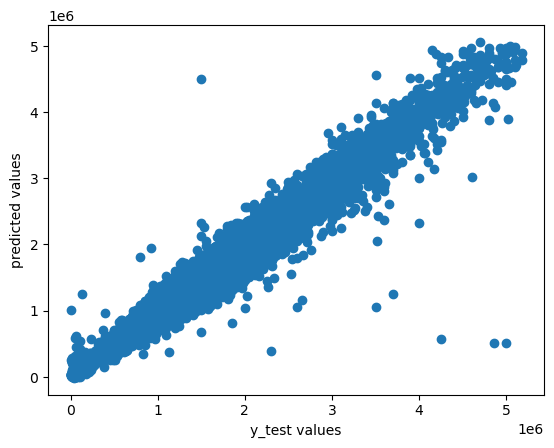

In [58]:
import matplotlib.pyplot as plt

plt.scatter(x = y_test.values,y =  y_pred)
plt.xlabel("y_test values")
plt.ylabel("predicted values")
plt.show()



In [59]:
stuff = {"model": best_model, "columns": x_train.columns, "idx": feat_index}

In [67]:
import pickle
filename = f"sale_model_parameters.sav"
with open(os.getcwd()+f"\\models\\{filename}", 'wb') as f:
    pickle.dump(stuff, open(os.getcwd()+f"\\models\\{filename}", 'wb'))


In [66]:
print(os.getcwd()+f"\\models\\{filename}")

d:\Documents\Github\real-estate-predictor\models\sale_model_parameters.sav


In [68]:
result = pickle.load(open(os.getcwd()+f"\\models\\{filename}", 'rb'))
loaded = result['model']

In [69]:
loaded.predict(test_x)

array([1805764.07623123, 1279186.71517894,  890419.6161658 , ...,
        777430.99499938,  829225.37876945, 1100140.68445407])